# ESC SPMe: Plot I, V, T, and SOC for all cells

Conclusions: Because the model overpredicts current, I also let it overpredict temperature as opposed to tuning Cp and h to fit the data. Using the lumped thermal model, we see that the effect of decomposition heating is minimal, which was expected. SEI decomposition is also the only decomp reaction contributing to heating which was expected.  

In [1]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
# sys.path.insert(1,r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\venv\Lib\MiKTeX')
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from mpl_toolkits.mplot3d import axes3d
from scipy.interpolate import RegularGridInterpolator as rgi
from scipy.interpolate import interp2d
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
import dfols
from scipy import integrate, signal, constants
import matplotlib as mpl
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 11,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)
# pybamm.settings.max_smoothing = 'exact'

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


In [2]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External short resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

# Define parameter functions

In [3]:
from pybamm import exp, constants, Parameter


def modified_graphite_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Negative electrode diffusion coefficient [m2.s-1]")
    # D_ref = 16*5.0 * 10 ** (-15)
    E_D_s = 42770
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (sto - 0)/(0.8321-0)
    k = 1.12070451*soc + 0.09209274 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate) only exclude kn>9

    return D_ref*pybamm.maximum(k,0.01) #*arrhenius # *(-0.9 * sto + 1)

def modified_NMC_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Positive electrode diffusion coefficient [m2.s-1]")
    E_D_s = 18550
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (0.837-sto)/(0.837-0.034)
    k =  4.7302281*soc**2  -4.5023245*soc + 1.26466141 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate)
    
    return D_ref * pybamm.maximum(k,0.01) #*arrhenius

def modified_electrolyte_diffusivity_PeymanMPM(c_e, T):
    # D_c_e = 5.35 * 10 ** (-10)
    D_c_e =  Parameter("Typical electrolyte diffusivity [m2.s-1]")
    return D_c_e

def modified_electrolyte_conductivity_PeymanMPM(c_e, T):
    # sigma_e = 1.3
    sigma_e = Parameter("Typical electrolyte conductivity [m2.s-1]")
    E_k_e = 34700
    return sigma_e


def modified_NMC_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4.824 * 10 ** (-6)  # (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 /T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #* arrhenius
    )

def modified_graphite_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4*1.061 * 10 ** (-6)  # unit has been converted units are (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #*arrhenius
    )


# Load data

In [4]:
Q_nom = 4.6
t_end = 15*60

def load_data(SOC_0, SOC_name):
    # load data import ESC data from file
    raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
    esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
    esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
    T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
    data['Cell Temperature'][data['Cell Temperature']>140] = None
    data.interpolate(inplace=True)
    data['Current Shunt'] = -data['Current Shunt']
    data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
    data['Force'] = (data['Force'] - data['Force'].loc[esc_start])*9.81
    df_labels = ['t', 'V', 'Temp','I', 'F']
    data.set_axis(df_labels, axis=1, inplace=True)
    data['I_C'] = data.I/Q_nom 
    AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
    if SOC_name =='100B':
        data['V'][(data.t[0:-1]>800) & (data.V>0.1)]  = None # remove voltage recovery on 100B

    T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data.reset_index(drop=True, inplace=True)

    return data, T_amb_0

data, T_amb = load_data(1, '100A')
display(data)

C:\Users\Vivian\AppData\Local\Temp\ipykernel_26556\3476336824.py:17: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_26556\3476336824.py:19: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600


,t,V,Temp,I,F,I_C,SOC
0,0.000,4.176052,24.111259,0.824988,0.000000,0.179345,0.999296
1,0.100,1.564826,24.140908,232.204691,0.603288,50.479281,0.997894
2,0.200,1.543099,24.121142,232.228600,0.698544,50.484478,0.996493
3,0.300,1.521092,24.150790,231.838083,1.174824,50.399583,0.995090
4,0.400,1.515830,24.121142,232.698815,1.174824,50.586699,0.993685
...,...,...,...,...,...,...,...
8996,899.602,0.019834,69.558434,2.151935,-125.515679,0.467812,0.302791
8997,899.702,0.019834,69.548850,2.163890,-125.388671,0.470411,0.302777
8998,899.802,0.019754,69.568017,2.279450,-125.642687,0.495533,0.302764
8999,899.902,0.019874,69.548850,2.143966,-125.198159,0.466079,0.302751


# Run simulations

In [5]:
param_update_iso = {        
    "Negative electrode diffusivity [m2.s-1]": modified_graphite_diffusivity_PeymanMPM,
    "Positive electrode diffusivity [m2.s-1]": modified_NMC_diffusivity_PeymanMPM,
    "Electrolyte diffusivity [m2.s-1]": modified_electrolyte_diffusivity_PeymanMPM,
    "Electrolyte conductivity [S.m-1]": modified_electrolyte_conductivity_PeymanMPM,
    # "Initial concentration in electrolyte [mol.m-3]":1000, #*1.3
    "Negative electrode exchange-current density [A.m-2]": modified_graphite_electrolyte_exchange_current_density_PeymanMPM,
    "Positive electrode exchange-current density [A.m-2]": modified_NMC_electrolyte_exchange_current_density_PeymanMPM,
    "Negative electrode OCP entropic change [V.K-1]":0,
    "Positive electrode OCP entropic change [V.K-1]":0,
    }

In [6]:
Cps = {'100A': 1.20962392, '100B': 1.09465293, '75': 0.96645967, '50': 1.0120845}
hs = {'100A': 19.99019775, '100B': 17.81984063, '75': 19.81810618, '50': 20.00621175}
R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007}
R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067}
k_A_sei = {'100A':  0.07912785, '100B':0.238155, '75':0.04571944, '50':0.05716926}

Cps.update({'avg': np.mean([Cps[k] for k in Cps.keys()])})
hs.update({'avg': np.mean([hs[k] for k in hs.keys()])})
R_tabs.update({'avg': np.mean([R_tabs[k] for k in R_tabs.keys()])})
R_escs.update({'avg': np.mean([R_escs[k] for k in R_escs.keys()])})
k_A_sei.update({'avg': np.mean([k_A_sei[k] for k in k_A_sei.keys()])})

In [7]:
t_end = 2000
def sim_ESC(SOC_0, SOC_name, param_update = {}, SOC_param = "", k_h_sei = 1):    # need to "data,T_amb_0 = load_data(SOC_0, SOC_name)" before running
    # data, T_amb = load_data(SOC_0, SOC_name)
    R_tab = pybamm.Parameter("Tabbing resistance [Ohm]")
    R_ext = pybamm.Parameter("External resistance [Ohm]")
    
    if SOC_param =="":
        SOC_param = SOC_name
    option = {
        "thermal": "lumped",
        "decomposition": "true", 
        "operating mode": ExternalCircuitResistanceFunction(),
        "cell geometry": "arbitrary",
        "venting":"true",
        # "loss of active material": "electrolyte dryout", 
    }

    model = pybamm.lithium_ion.SPMe(options = option)
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    
    param.update({
        # "Initial fraction of Li in SEI": 0.15,
        "Frequency factor for SEI decomposition [s-1]": 2.25E15*k_A_sei[SOC_param],
        "Enthalpy of SEI decomposition [J.kg-1]":257000*k_h_sei,
        # "Number of electrodes connected in parallel to make a cell": 10,
        'Internal short resistance [Ohm]':1e16,
        "Tabbing resistance [Ohm]":  R_tabs[SOC_param],#0.0041,D
        "External short resistance [Ohm]": R_escs[SOC_param], # 0.0067
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
        "Lower voltage cut-off [V]": 0,
        "Ambient temperature [K]":T_amb + 273.15,
        "Initial temperature [K]": T_amb + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        "Initial cell compression stress [kPa]": data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        # "Negative current collector surface heat transfer coefficient [W.m-2.K-1]": h,  
        # "Positive current collector surface heat transfer coefficient [W.m-2.K-1]": h,  
        # "Negative tab heat transfer coefficient [W.m-2.K-1]":h,  
        # "Positive tab heat transfer coefficient [W.m-2.K-1]":h,  
        # "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":hs[SOC_param],
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps[SOC_param],
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps[SOC_param],
    }, check_already_exists = False)

    param.update(param_update, check_already_exists = False)
    
    V = model.variables["Terminal voltage [V]"]
    I = model.variables["Current [A]"]
    model.variables.update({
        "Terminal voltage [V]": V - I*R_tab,
        "Actual resistance [Ohm]":V/I,
        }
    )
    
    dt = 0.1
    t_eval = np.arange(0, t_end, dt) #16*60
    solver = pybamm.CasadiSolver(mode="safe", dt_max = 10) #, extra_options_setup={"max_num_steps": 10000}
    sim = pybamm.Simulation(model, parameter_values = param, solver=solver) #, solver=solver
    solution = sim.solve( initial_soc=SOC_0, t_eval = t_eval)
    return solution

# solution = sim_ESC(0.75, '75')


# PLOT: R sweep log time

In [8]:
SOC_names = ['100A']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
SOC_name = SOC_names[0]
SOC_0 = SOC_0s[SOC_name]
# data,T_amb = load_data(SOC_0, SOC_name)

solutions_avg = []
R_sweeps = [0.0025, 0.005] + list(np.arange(0.01,0.11,0.01))#[0.1, 0.05, 0.04, 0.03,0.02, 0.01]
R_sweeps.reverse()

for R in R_sweeps: 
    print('R = ' + str(R))
    param_update_iso.update({
        "External short resistance [Ohm]": R,
    })
    solution_avg= sim_ESC(SOC_0, SOC_name, param_update = param_update_iso, SOC_param = 'avg')
    solutions_avg.append(solution_avg)

R = 0.09999999999999999


R = 0.09
R = 0.08
R = 0.06999999999999999
R = 0.060000000000000005
R = 0.05
R = 0.04
R = 0.03
R = 0.02
R = 0.01
R = 0.005
R = 0.0025


0.09999999999999999


NameError: name 'soc' is not defined

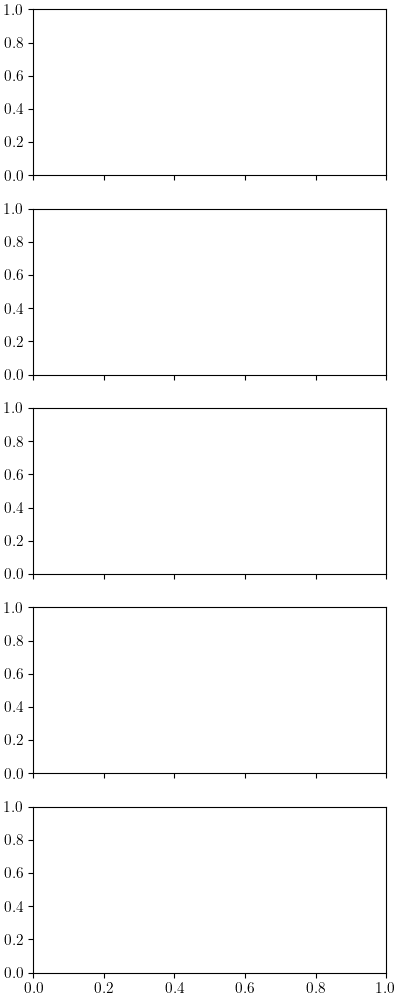

In [9]:
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = [str(np.round(R,3)) + '$\Omega$' for R in R_sweeps]
fig, ax = plt.subplots(5,  1, figsize=(4, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['-'] #['--',':','-.']*5

cmap = plt.cm.get_cmap('coolwarm', len(R_sweeps))
# rgba = cmap(0.5)
sim_colors = [mpl.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]#['r','g','b','m','c','y']*5

# t_refs = [1, 1*60, 5*60]
# t_refs_labels = ['1 s', '1 min', '5 min']

h_list = []
Resc_list =[]
soc_f_list = []
t_discharge_list = []
max_sigma_list = []
max_T_list = []
I_min = 1 #C-rate

# for each R..
for i, solution in enumerate(solutions_avg):    
    SOC_0 = SOC_0s[SOC_names[0]]
    print(R_sweeps[i])
    
    # plot
    t = solution["Time [s]"].entries
    discharge_end = np.where(soc<0.5)[0][0]
    x = solution["x [m]"].entries[:, 0]
    x_plot = t
    xlabel = "Time [s]"
    # data_color = 'k'
    sim_color = sim_colors[i]
    sim_ls = linestyles[0]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    # data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    I = solution['C-rate'](t)
    # e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
    ax[0].semilogx(x_plot, I, linestyle=sim_ls, color = sim_color, label=sim_set_labels[i])
    # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
    # ax[0,i].set_xlabel(xlabel)
    ax[0].set_ylabel('C-rate', labelpad=0)
    # ax[0].set_title(SOC_names[i] + "\% SOC$_0$") #, pad = 30
    # ax[0].set_ylim([0,80])

    V = solution['Terminal voltage [V]']
    ax[1].semilogx(x_plot, V(t),linestyle=sim_ls, color = sim_color)
    # ax[1,i].set_xlabel(xlabel)
    ax[1].set_ylabel('Terminal voltage [V]', labelpad=0)
    # ax[1].set_ylim([0,2])

    T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    ax[2].semilogx(x_plot, T,linestyle=sim_ls, color = sim_color)  
    # ax[2,i].set_xlabel(xlabel)
    ax[2].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    # ax[2].set_ylim([20,150])
    
        
    soc = SOC_0 - integrate.cumtrapz(I,t)/3600
    soc = np.insert(soc,0,SOC_0)
    ax[3].semilogx(x_plot, soc,linestyle=sim_ls, color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].set_xlabel(xlabel)
    ax[3].set_ylabel('SOC',labelpad=-1)
    # ax[3].set_ylim([0,1])

    sigma_max = 42.35277961 # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = 0  
        t_vent_sim = data.t[np.where(sigma_plot==0)[0][0]]
    

    # discharge_end = np.where(I<I_min)[0][0]
    discharge_end = np.where(soc<0.5)[0][0]
    soc_f = soc[discharge_end]
    t_discharge = t[discharge_end]
    max_T = max(T)
    max_sigma = max(sigma_plot)

    Resc_list.append(R)
    soc_f_list.append(soc_f)
    t_discharge_list.append(t_discharge)
    max_sigma_list.append(max_sigma)
    max_T_list.append(max_T)
    
    ax[4].semilogx([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = 'k') #(out.P_est-P_atm)/1000-sigma_0/1000
    ax[4].semilogx(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    ax[4].set_ylim([0,70])
    ax[4].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4].set_xlabel(xlabel)

plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='lower center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 0.88))
plt.xlim([0,t[-1]])
plt.tight_layout()
plt.savefig('./figs/R_sweep_log.eps', format='eps', dpi = 300)
plt.show()

df = pd.DataFrame(list(zip(R_sweeps,soc_f_list, t_discharge_list, max_sigma_list, max_T_list)), 
                  columns= ['R_esc','SOC_f', 't_discharge','max_sigma', 'max_T_list'])
display(df)

0.09999999999999999
0.09
0.08
0.06999999999999999
0.060000000000000005
0.05
0.04
0.03
0.02
0.01
0.005
0.0025


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


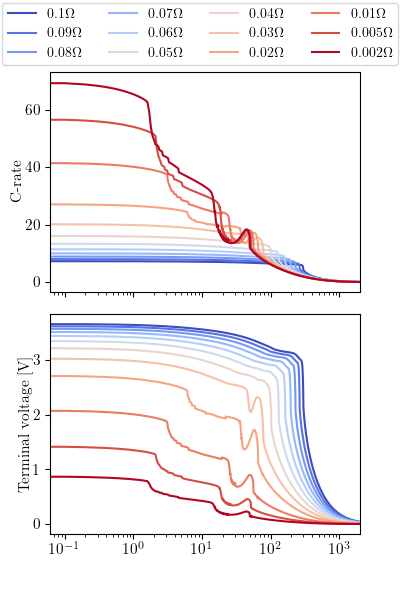

,R_esc,SOC_f,t_discharge
0,0.1000,0.499905,145.3
1,0.0900,0.499905,145.3
2,0.0800,0.499905,145.3
3,0.0700,0.499905,145.3
4,0.0600,0.499905,145.3
5,0.0500,0.499905,145.3
6,0.0400,0.499905,145.3
7,0.0300,0.499905,145.3
8,0.0200,0.499905,145.3
9,0.0100,0.499905,145.3


In [ ]:
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = [str(np.round(R,3)) + '$\Omega$' for R in R_sweeps]
fig, ax = plt.subplots(2,  1, figsize=(4, 6), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['-'] #['--',':','-.']*5

cmap = plt.cm.get_cmap('coolwarm', len(R_sweeps))
# rgba = cmap(0.5)
sim_colors = [mpl.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]#['r','g','b','m','c','y']*5

# t_refs = [1, 1*60, 5*60]
# t_refs_labels = ['1 s', '1 min', '5 min']

h_list = []
Resc_list =[]
soc_f_list = []
t_discharge_list = []
max_sigma_list = []
max_T_list = []
I_min = 1 #C-rate

# for each R..
for i, solution in enumerate(solutions_avg):    
    SOC_0 = SOC_0s[SOC_names[0]]
    print(R_sweeps[i])
    
    # plot
    t = solution["Time [s]"].entries
    discharge_end = np.where(soc<0.5)[0][0]
    x = solution["x [m]"].entries[:, 0]
    x_plot = t
    xlabel = "Time [s]"
    # data_color = 'k'
    sim_color = sim_colors[i]
    sim_ls = linestyles[0]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    # data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    I = solution['C-rate'](t)
    # e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
    ax[0].semilogx(x_plot, I, linestyle=sim_ls, color = sim_color, label=sim_set_labels[i])
    # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
    # ax[0,i].set_xlabel(xlabel)
    ax[0].set_ylabel('C-rate', labelpad=0)
    # ax[0].set_title(SOC_names[i] + "\% SOC$_0$") #, pad = 30
    # ax[0].set_ylim([0,80])

    V = solution['Terminal voltage [V]']
    ax[1].semilogx(x_plot, V(t),linestyle=sim_ls, color = sim_color)
    # ax[1,i].set_xlabel(xlabel)
    ax[1].set_ylabel('Terminal voltage [V]', labelpad=0)
    # ax[1].set_ylim([0,2])

    # T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    # ax[2].semilogx(x_plot, T,linestyle=sim_ls, color = sim_color)  
    # # ax[2,i].set_xlabel(xlabel)
    # ax[2].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    # # ax[2].set_ylim([20,150])
    
        
    # soc = SOC_0 - integrate.cumtrapz(I,t)/3600
    # soc = np.insert(soc,0,SOC_0)
    # ax[3].semilogx(x_plot, soc,linestyle=sim_ls, color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # # ax[3,i].set_xlabel(xlabel)
    # ax[3].set_ylabel('SOC',labelpad=-1)
    # # ax[3].set_ylim([0,1])

    # sigma_max = 42.35277961 # from either 100% (default) or 100%F cell
    # sigma = solution["Cell expansion stress [kPa]"].entries
    # sigma_plot = sigma.copy()
    # vent_check = np.argmax(sigma_plot>sigma_max)
    # if vent_check > 0:
    #     sigma_plot[vent_check::] = 0  
    #     t_vent_sim = data.t[np.where(sigma_plot==0)[0][0]]
    

    # discharge_end = np.where(I<I_min)[0][0]
    discharge_end = np.where(soc<0.5)[0][0]
    soc_f = soc[discharge_end]
    t_discharge = t[discharge_end]
    # max_T = max(T)
    # max_sigma = max(sigma_plot)

    Resc_list.append(R)
    soc_f_list.append(soc_f)
    t_discharge_list.append(t_discharge)
    # max_sigma_list.append(max_sigma)
    # max_T_list.append(max_T)
    
    # ax[4].semilogx([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = 'k') #(out.P_est-P_atm)/1000-sigma_0/1000
    # ax[4].semilogx(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    # ax[4].set_ylim([0,70])
    # ax[4].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    # ax[4].set_xlabel(xlabel)

plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='lower center', ncol=4, prop={'size': 10},  bbox_to_anchor=(0.5, 0.88))
plt.xlim([0,t[-1]])
plt.tight_layout()
plt.savefig('./figs/R_sweep_log_short.eps', format='eps', dpi = 300)
plt.show()

df = pd.DataFrame(list(zip(R_sweeps,soc_f_list, t_discharge_list)), 
                  columns= ['R_esc','SOC_f', 't_discharge'])
display(df)

# PLOT: R and h sweep

## Run simulations calculate metrics and create df

In [ ]:
SOC_names = ['100A']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
SOC_name = SOC_names[0]
SOC_0 = SOC_0s[SOC_name]
I_min = 1/10 #C-rate

solutions_list = []
R_sweep = list(np.linspace(0.005,0.1-0.005,20))
h_sweep = list(np.linspace(1,41,20))


param = pybamm.ParameterValues('Tran2023')
sigma_0 = data.F.iloc[0]/param['Active material surface area [m2]']/1000,

h_list = []
Resc_list =[]
soc_f_list = []
t_discharge_list = []
max_sigma_list = []
max_T_list = []

for h in h_sweep:
    solutions = []
    print('h = ' + str(h))
    for R in R_sweep: 
        # RUN SIMULATIONS
        param_update_iso.update({
            "External short resistance [Ohm]": R,
            "Total heat transfer coefficient [W.m-2.K-1]": h})
        solution= sim_ESC(SOC_0, SOC_name, param_update = param_update_iso, SOC_param = 'avg')

        # CALCULATE METRICS
        t = solution["Time [s]"].entries
        I = solution['C-rate'](t)

        discharge_end = np.where(I<I_min)[0][0]

        # calculate final soc
        SOC_0 = SOC_0s[SOC_names[0]]
        soc = SOC_0 - integrate.cumtrapz(I,t)/3600
        soc = np.insert(soc,0,SOC_0)
        soc_f = soc[discharge_end]

        # calculate discharge time  
        t_discharge = t[discharge_end]

        # max sigma
        sigma_max = 42.35277961 # from either 100A%
        sigma = solution["Cell expansion stress [kPa]"].entries
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
        max_sigma = max(sigma_plot)

        # max_T
        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        max_T = max(T)
        
        h_list.append(h)
        Resc_list.append(R)
        soc_f_list.append(soc_f)
        t_discharge_list.append(t_discharge)
        max_sigma_list.append(max_sigma)
        max_T_list.append(max_T)

        solutions.append(solution)
    solutions_list.append(solutions)

df = pd.DataFrame(list(zip(h_list,Resc_list,soc_f_list, t_discharge_list, max_sigma_list, max_T_list)), 
                  columns= ['h', 'R_esc','SOC_f', 't_discharge','max_sigma', 'max_T_list'])
# df = pd.DataFrame(list(zip(h_list,Resc_list,t_discharge_list, max_sigma_list)), 
                #   columns= ['h', 'R_esc', 't_discharge','max_sigma'])

df.to_pickle('R_h_sweep20.pkl')

df = pd.read_pickle('R_h_sweep.pkl')
R_sweep = np.unique(df.R_esc)
h_sweep = np.unique(df.h)
display(df)


h = 1.0
h = 3.1052631578947367
h = 5.2105263157894735
h = 7.315789473684211
h = 9.421052631578947
h = 11.526315789473683
h = 13.631578947368421
h = 15.736842105263158
h = 17.842105263157894
h = 19.94736842105263
h = 22.052631578947366
h = 24.157894736842103
h = 26.263157894736842
h = 28.36842105263158
h = 30.473684210526315
h = 32.578947368421055
h = 34.68421052631579
h = 36.78947368421053
h = 38.89473684210526
h = 41.0


,h,R_esc,SOC_f,t_discharge,max_sigma
0,1.0,0.00500,0.191057,1716.9,42.259115
1,1.0,0.01625,0.191003,1723.1,42.292554
2,1.0,0.02750,0.191011,1728.5,42.327357
3,1.0,0.03875,0.191015,1738.7,42.334949
4,1.0,0.05000,0.191020,1752.1,42.341802
...,...,...,...,...,...
76,41.0,0.05000,0.191016,1752.1,3.299012
77,41.0,0.06125,0.191014,1767.5,2.812334
78,41.0,0.07250,0.191014,1784.8,2.418528
79,41.0,0.08375,0.191017,1803.7,2.094471


## 3D plot R, h, exp

In [ ]:
# for i, h in enumerate(h_sweep):
#     for j, r in enumerate(R_sweep): 
df.max_sigma[(df.h == h_sweep[0]) & (df.R_esc == R_sweep[0])]

0    42.259115
Name: max_sigma, dtype: float64

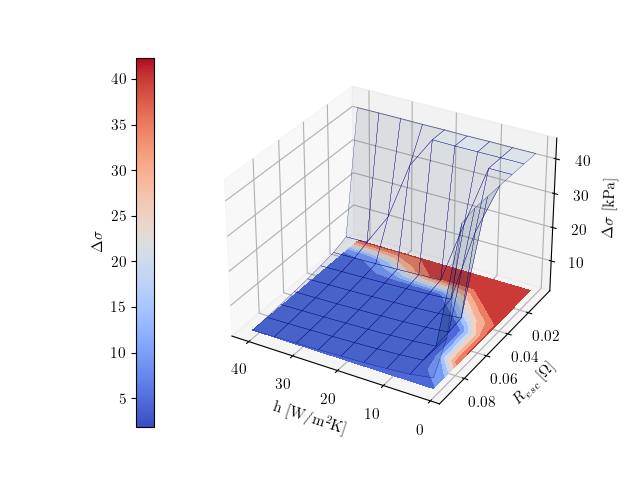

In [ ]:
ax = plt.figure().add_subplot(projection='3d')
X, Y = np.meshgrid(h_sweep, R_sweep)
Z = X.copy()
# make Z from df
for i, h in enumerate(h_sweep):
    for j, r in enumerate(R_sweep): 
        Z[j][i] = df.max_sigma[(df.h == h) & (df.R_esc == r)]

# interpolate
num_pts = 30
X1, Y1 = np.meshgrid(np.linspace(min(h_sweep), max(h_sweep), num_pts), np.linspace(min(R_sweep), max(R_sweep), num_pts))
x1 = np.linspace(min(h_sweep), max(h_sweep), num_pts)
y1 = np.linspace(min(R_sweep), max(R_sweep),num_pts)
f = interp2d(h_sweep, R_sweep, Z ) #kind='cubic'
# f = interp2d(h_sweep, R_sweep, Z, kind='cubic') #

Z1 = f(x1, y1)

# Plot the 3D surface
# ax.plot_surface(X, Y, Z,cmap=cm.coolwarm, linewidth=0) 
# ax.plot_surface(X1, Y1, Z1,cmap=cm.coolwarm, linewidth=0) # interpolated

# plot wire surface and projections on each "wall"
ax.plot_surface(X, Y, Z, edgecolor='navy',lw=0.2, alpha=0.1) 
ax.contourf(X, Y, Z, zdir='z', offset=ax.get_zlim()[0], cmap='coolwarm')
# ax.contourf(X, Y, Z, zdir='x', offset=ax.get_xlim()[0], cmap='coolwarm')
# ax.contourf(X, Y, Z, zdir='y', offset=ax.get_ylim()[0], cmap='coolwarm')

# ax.plot_surface(X1, Y1, Z1, edgecolor='navy',lw=0.05, alpha=0) 
# ax.contourf(X1, Y1, Z1, zdir='z', offset=ax.get_zlim()[0], cmap='coolwarm') #RdYlBu, RdYlGn
# ax.contourf(X1, Y1, Z1, zdir='x', offset=ax.get_xlim()[0], cmap='coolwarm')
# ax.contourf(X1, Y1, Z1, zdir='y', offset=ax.get_ylim()[0], cmap='coolwarm')

m = cm.ScalarMappable(cmap='coolwarm')
m.set_array(Z)
plt.colorbar(m, location = 'left',label = "$\Delta \sigma$") #, shrink=0.6
ax.set(xlabel='h [W/m$^2$K]', ylabel='$R_{esc}$  [$\Omega$]', zlabel='$\Delta\sigma$ [kPa]') #xlim=(-40, 40), ylim=(-40, 40), zlim=(-100, 100), 
ax.view_init(30, 120)
# plt.savefig('./figs/R_h_sigma_sweep.eps', format='eps', dpi = 300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


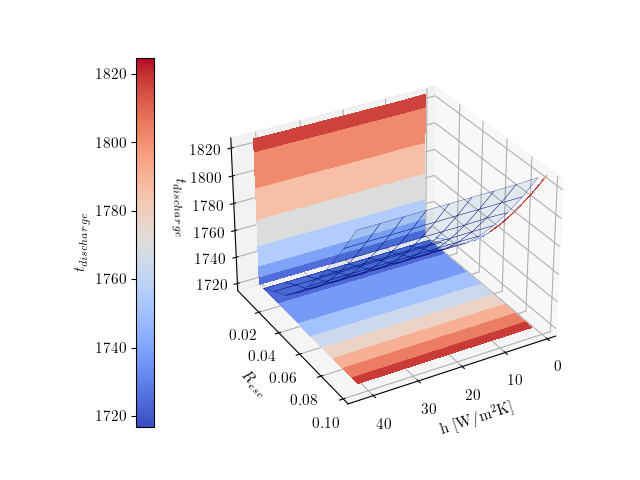

In [ ]:
ax = plt.figure().add_subplot(projection='3d')
X, Y = np.meshgrid(h_sweep, R_sweep)
Z = X.copy()
# make Z from df
for i, h in enumerate(h_sweep):
    for j, r in enumerate(R_sweep): 
        Z[j][i] = df.t_discharge[(df.h == h) & (df.R_esc == r)]

# interpolate
num_pts = 30
X1, Y1 = np.meshgrid(np.linspace(min(h_sweep), max(h_sweep), num_pts), np.linspace(min(R_sweep), max(R_sweep), num_pts))
x1 = np.linspace(min(h_sweep), max(h_sweep), num_pts)
y1 = np.linspace(min(R_sweep), max(R_sweep),num_pts)
f = interp2d(h_sweep, R_sweep, Z ) #kind='cubic'
# f = interp2d(h_sweep, R_sweep, Z, kind='cubic') #

Z1 = f(x1, y1)

# Plot the 3D surface
# ax.plot_surface(X, Y, Z,cmap=cm.coolwarm, linewidth=0) 
# ax.plot_surface(X1, Y1, Z1,cmap=cm.coolwarm, linewidth=0) # interpolated

# plot wire surface and projections on each "wall"
ax.plot_surface(X, Y, Z, edgecolor='navy',lw=0.2, alpha=0.1) 
ax.contourf(X, Y, Z, zdir='z', offset=ax.get_zlim()[0], cmap='coolwarm')
ax.contourf(X, Y, Z, zdir='x', offset=ax.get_xlim()[0], cmap='coolwarm')
ax.contourf(X, Y, Z, zdir='y', offset=ax.get_ylim()[0], cmap='coolwarm')

# ax.plot_surface(X1, Y1, Z1, edgecolor='navy',lw=0.2, alpha=0.0) 
# ax.contourf(X1, Y1, Z1, zdir='z', offset=ax.get_zlim()[0], cmap='coolwarm') #RdYlBu, RdYlGn
# ax.contourf(X1, Y1, Z1, zdir='x', offset=ax.get_xlim()[0], cmap='coolwarm')
# ax.contourf(X1, Y1, Z1, zdir='y', offset=ax.get_ylim()[0], cmap='coolwarm')

m = cm.ScalarMappable(cmap='coolwarm')
m.set_array(Z)
plt.colorbar(m, location = 'left',label = "$t_{discharge}$") #, shrink=0.6
ax.set(xlabel='h [W/m$^2$K]', ylabel='$R_{esc}$', zlabel='$t_{discharge}$') #xlim=(-40, 40), ylim=(-40, 40), zlim=(-100, 100), 
ax.view_init(30, 60)
plt.savefig('./figs/R_h_t_discharge_sweep.eps', format='eps', dpi = 300)
plt.show()

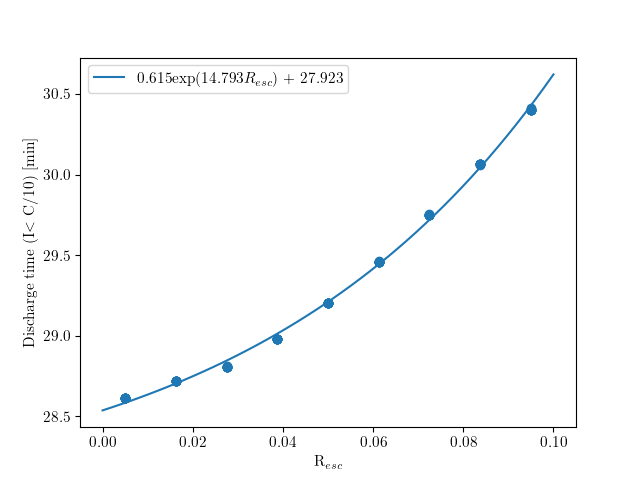

In [ ]:
from scipy.optimize import curve_fit

def func(x, a, b, c):
    return a * np.exp(-b * x) + c

fig, ax = plt.subplots(1,1)
ax.scatter(df.R_esc, df.t_discharge/60)
ax.set_ylabel('Discharge time (I$<$ C/10) [min]')
ax.set_xlabel('R$_{esc}$')

popt, pcov = curve_fit(func, df.R_esc, df.t_discharge/60)
# p = np.polyfit(df.R_esc, np.log(df.t_discharge/60), 1)
x_fit = np.linspace(0,0.10)
y_fit = func(x_fit, *popt)
ax.plot(x_fit,y_fit, label = str(round(popt[0],3)) + 'exp(' + str(round(-popt[1],3)) + '$R_{esc}$) + ' + str(round(popt[2],3)))
ax.legend()

In [ ]:
R_water = 20
print(func(R_water, *popt)/60/24)

1.3309022462455442e+125


# Archive

h = 10


KeyboardInterrupt: 

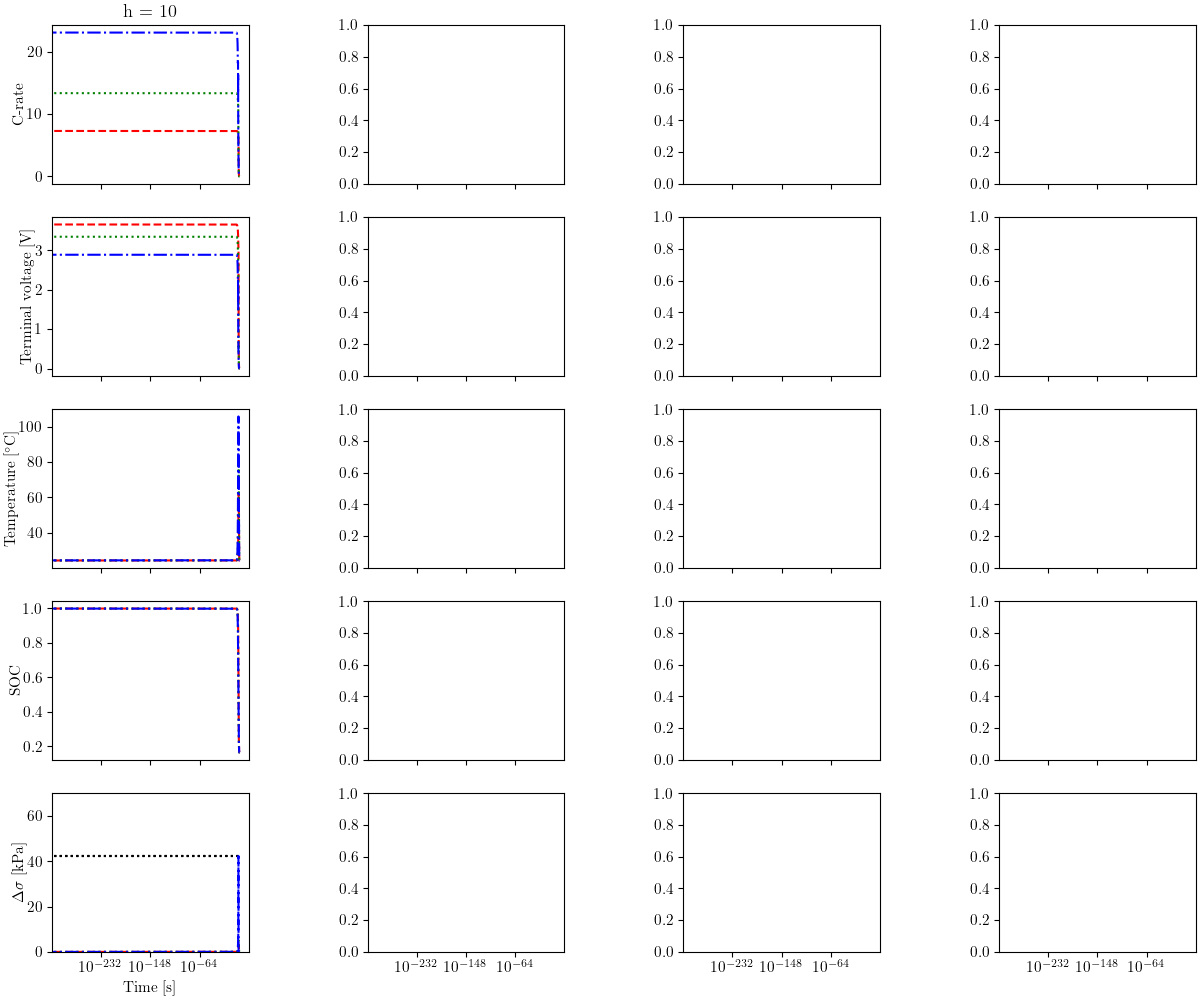

In [ ]:
param = pybamm.ParameterValues('Tran2023')
fig, ax = plt.subplots(5,  len(solutions_list), figsize=(3*len(solutions_list), 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*5
sim_colors = ['r','g','b','m','c','y']*5

# t_refs = [1, 1*60, 5*60]
# t_refs_labels = ['1 s', '1 min', '5 min']

# for each R..
for k, solutions in enumerate(solutions_list):
    sim_set_labels = [str(R) + '$\Omega$' for R in R_sweeps]
    column_title = 'h = ' + str(h_sweep[k])
    print(column_title)
    
    for i, solution in enumerate(solutions):    
        SOC_0 = SOC_0s[SOC_names[0]]

        # plot
        t = solution["Time [s]"].entries
        x = solution["x [m]"].entries[:, 0]
        x_plot = t
        xlabel = "Time [s]"
        # data_color = 'k'
        sim_color = sim_colors[i]
        sim_ls = linestyles[i]

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        # data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

        I = solution['C-rate']
        # e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
        ax[0,k].semilogx(x_plot, I(t), linestyle=sim_ls, color = sim_color, label=sim_set_labels[i])
        # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
        # ax[0,i].set_xlabel(xlabel)
        ax[0,k].set_ylabel('C-rate', labelpad=0)
        ax[0,k].set_title(column_title) #, pad = 30
        # ax[0].set_ylim([0,80])

        V = solution['Terminal voltage [V]']
        ax[1,k].semilogx(x_plot, V(t),linestyle=sim_ls, color = sim_color)
        # ax[1,i].set_xlabel(xlabel)
        ax[1,k].set_ylabel('Terminal voltage [V]', labelpad=0)
        # ax[1].set_ylim([0,2])

        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        ax[2,k].semilogx(x_plot, T,linestyle=sim_ls, color = sim_color)  
        # ax[2,i].set_xlabel(xlabel)
        ax[2,k].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
        # ax[2].set_ylim([20,150])

        soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
        soc = np.insert(soc,0,SOC_0)
        ax[3,k].semilogx(x_plot, soc,linestyle=sim_ls, color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].set_xlabel(xlabel)
        ax[3,k].set_ylabel('SOC',labelpad=0)
        # ax[3].set_ylim([0,1])

        sigma_max = 42.35277961 # from either 100% (default) or 100%F cell
        sigma = solution["Cell expansion stress [kPa]"].entries
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
            t_vent_sim = data.t[np.where(sigma_plot==0)[0][0]]

        ax[4,k].semilogx([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = 'k') #(out.P_est-P_atm)/1000-sigma_0/1000
        ax[4,k].semilogx(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
        ax[4,k].set_ylim([0,70])
        ax[4,k].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
        ax[4,k].set_xlabel(xlabel)

plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0,0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,t[-1]])
plt.tight_layout()
plt.savefig('./figs/Rh_sweep_log.eps', format='eps', dpi = 300)
plt.show()


## PLOT: R sweep linear time

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


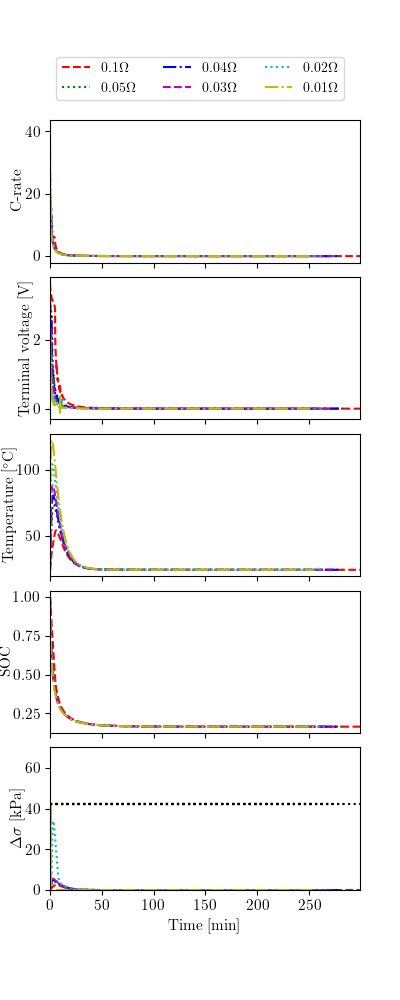

In [ ]:
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = [str(R) + '$\Omega$' for R in R_sweeps]
fig, ax = plt.subplots(5,  1, figsize=(4, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*5
sim_colors = ['r','g','b','m', 'c', 'y']*5

# t_refs = [1, 1*60, 5*60]
# t_refs_labels = ['1 s', '1 min', '5 min']

# for each R..
for i, solution in enumerate(solutions_avg): 
    print(sim_set_labels[i])   
    SOC_0 = SOC_0s[SOC_names[0]]

    # plot
    t = solution["Time [s]"].entries
    x = solution["x [m]"].entries[:, 0]
    x_plot = t/60
    xlabel = "Time [min]"
    # data_color = 'k'
    sim_color = sim_colors[i]
    sim_ls = linestyles[i]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    # data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    I = solution['C-rate']
    # e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
    ax[0].plot(x_plot, I(t), linestyle=sim_ls, color = sim_color, label=sim_set_labels[i])
    # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
    # ax[0,i].set_xlabel(xlabel)
    ax[0].set_ylabel('C-rate', labelpad=0)
    # ax[0].set_title(SOC_names[i] + "\% SOC$_0$") #, pad = 30
    # ax[0].set_ylim([0,80])

    V = solution['Terminal voltage [V]']
    ax[1].plot(x_plot, V(t),linestyle=sim_ls, color = sim_color)
    # ax[1,i].set_xlabel(xlabel)
    ax[1].set_ylabel('Terminal voltage [V]', labelpad=0)
    # ax[1].set_ylim([0,2])

    T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    ax[2].plot(x_plot, T,linestyle=sim_ls, color = sim_color)  
    # ax[2,i].set_xlabel(xlabel)
    ax[2].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    # ax[2].set_ylim([20,150])

    soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
    soc = np.insert(soc,0,SOC_0)
    ax[3].plot(x_plot, soc,linestyle=sim_ls, color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].set_xlabel(xlabel)
    ax[3].set_ylabel('SOC',labelpad=0)
    # ax[3].set_ylim([0,1])

    sigma_max = 42.35277961 # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = 0  
        t_vent_sim = data.t[np.where(sigma_plot==0)[0][0]]

    ax[4].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = 'k') #(out.P_est-P_atm)/1000-sigma_0/1000
    ax[4].plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    ax[4].set_ylim([0,70])
    ax[4].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4].set_xlabel(xlabel)

# plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,solutions_avg[0]['Time [s]'].entries[-1]/60])
plt.tight_layout()
plt.savefig('./figs/R_sweep_linear.eps', format='eps', dpi = 300)
plt.show()
